**<span style="font-size:20px; color: LightBlue;">This file is created for ROC AUC comparison for models</span>**

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Loading the variable from each model files
y_true = np.load("results/y_true.npy")
logistic_scores = np.load("results/logistic_y_prob.npy")
svm_scores = np.load("results/svm_y_prob.npy")
xgb_probs = np.load("results/xgb_y_prob.npy")

**<span style="font-size:20px; color: LightBlue;">Functions to calculate ROC AUC</span>**

In [ ]:
#Function to create the ROC curve for plotting
def roc_curve(y_true, y_scores):
    thresholds = sorted(set(y_scores), reverse=True)

    tpr_list = []
    fpr_list = []

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)

        TP = np.sum((y_true == 1) & (y_pred == 1))
        FP = np.sum((y_true == 0) & (y_pred == 1))

        TPR = TP / P if P != 0 else 0
        FPR = FP / N if N != 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    fpr_list = [0] + fpr_list + [1]
    tpr_list = [0] + tpr_list + [1]

    return np.array(fpr_list), np.array(tpr_list)



In [ ]:
# Function to calculate AUC value 
def auc_manual(fpr, tpr):
    auc = 0
    for i in range(1, len(fpr)):
        auc += (fpr[i] - fpr[i-1]) * (tpr[i] + tpr[i-1]) / 2
    return auc

**<span style="font-size:20px; color: LightBlue;">Plotting the comparison plot of ROC-AUC for all the models together</span>**

In [ ]:
# Logistic Regression
fpr_log, tpr_log = roc_curve(y_true, logistic_scores)
auc_log = auc_manual(fpr_log, tpr_log)

# SVM
fpr_svm, tpr_svm = roc_curve(y_true, svm_scores)
auc_svm = auc_manual(fpr_svm, tpr_svm)

# XGBoost
fpr_xgb, tpr_xgb = roc_curve(y_true, xgb_probs)
auc_xgb = auc_manual(fpr_xgb, tpr_xgb)

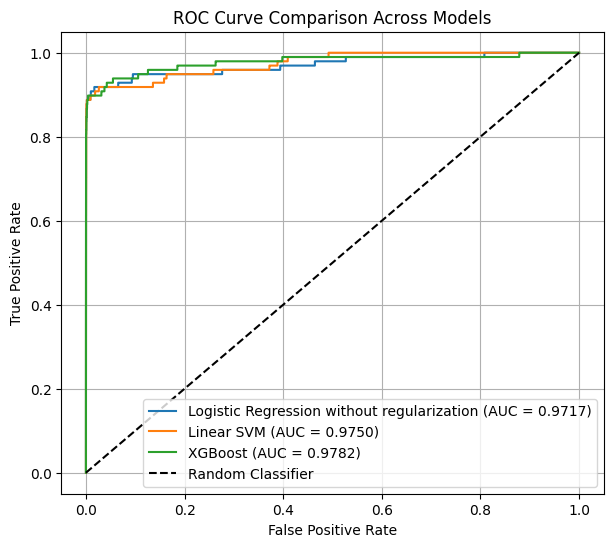

In [17]:
# Plotting the ROC graphs
plt.figure(figsize=(7, 6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression without regularization (AUC = {auc_log:.4f})")
plt.plot(fpr_svm, tpr_svm, label=f"Linear SVM (AUC = {auc_svm:.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.4f})")

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [13]:
# Printing final AUC values for each model
print("AUC Scores:")
print(f"Logistic Regression without Regularization: {auc_log:.4f}")
print(f"Linear SVM: {auc_svm:.4f}")
print(f"Tuned XGBoost: {auc_xgb:.4f}")

AUC Scores:
Logistic Regression without Regularization: 0.9717
Linear SVM: 0.9750
Tuned XGBoost: 0.9782
